# Simulazione d'esame Laboratorio di Programmazione 2

## Esercizio 1

1. Crea un vettore NumPy con i seguenti **canoni mensili d'affitto** (in euro) per 4 appartamenti: **720, 980, 650, 1200**

2. Calcola la **spesa totale mensile** sostenuta dagli inquilini.

3. Il proprietario dell'appartamento da **1200 €** decide di **aumentare l’affitto del 12%**.
    - Modifica il vettore per applicare l’aumento.
    - L’importo aggiornato deve essere esattamente **1344,00 €**, controlla se appare **esattamente** nel tuo array.


4. L'inquilino dell'appartamento da **650 €** ottiene uno **sconto del 10%**.
    - Applica la modifica.

5. Gli altri due appartamenti (**720 € e 980 €**) subiscono un **aumento del 5%**.
    - Aggiorna il vettore di conseguenza.

7. Calcola la **nuova spesa totale mensile** dopo tutti i cambiamenti.

8. Infine: quanto ha influito **l’aumento dell’affitto più alto** sulla spesa complessiva?

    (Suggerimento: confronta la spesa totale **prima di qualsiasi modifica** e **dopo il solo aumento del canone a 1200 €**.)


In [18]:
import numpy as np

In [19]:

#Crea un vettore NumPy con i seguenti **canoni mensili d'affitto** (in euro) per 4 appartamenti: **720, 980, 650, 1200**

canoni_mensili = np.array([720,980,650,1200], dtype=float)

In [20]:
# Calcola la **spesa totale mensile** sostenuta dagli inquilini.

spesa0 = sum(canoni_mensili)

In [21]:
#  Il proprietario dell'appartamento da **1200 €** decide di **aumentare l’affitto del 12%**.
#     - Modifica il vettore per applicare l’aumento.
#     - L’importo aggiornato deve essere esattamente **1344,00 €**, controlla se appare **esattamente** nel tuo array.

idx = canoni_mensili==1200
canoni_mensili[idx]*=(112/100)

np.isclose(canoni_mensili, 1344).any()

spesa_post1200 = sum(canoni_mensili)



In [22]:
# 4. L'inquilino dell'appartamento da **650 €** ottiene uno **sconto del 10%**.
#     - Applica la modifica.
idx = canoni_mensili==650
canoni_mensili[idx]*=(90/100)
canoni_mensili

array([ 720.,  980.,  585., 1344.])

In [23]:
# 5. Gli altri due appartamenti (**720 € e 980 €**) subiscono un **aumento del 5%**.
#     - Aggiorna il vettore di conseguenza.

idx1 = canoni_mensili==720
idx2 = canoni_mensili==980
canoni_mensili[idx1]*=(105/100)
canoni_mensili[idx2]*=(105/100)
canoni_mensili

array([ 756., 1029.,  585., 1344.])

In [24]:
#Calcola la **nuova spesa totale mensile** dopo tutti i cambiamenti.
spesa1 = sum(canoni_mensili)

In [30]:
# 8. Infine: quanto ha influito **l’aumento dell’affitto più alto** sulla spesa complessiva?

#     (Suggerimento: confronta la spesa totale **prima di qualsiasi modifica** e **dopo il solo aumento del canone a 1200 €**.)

((spesa_post1200-spesa0)/spesa1)*100

np.float64(3.877221324717286)

## Esercizio 2

Consideriamo un semplice processo di random walk (cammino aleatorio) in una dimensione:
a ogni passo temporale, un camminatore si sposta a destra (+1) o a sinistra (-1) con uguale probabilità. Supponiamo che il camminatore parta sempre da x=0.

1. Scrivi una funzione che simula il cammino per n passi ed N camminatori e restituisce due array. Il primo rappresenta la media della posizione ad ogni passo degli N camminatori ed il secondo la deviazione standard della posizione ad ogni passo degli N camminatori.

2. Fai prima il plot della media delle posizione degli N camminatori per 100 passi 

3. Fai il plot con anche la devizione standard.  La deviazione standard diminuisce all'aumentare del campione? Che andamento ha la deviazione standard rispeto l tempo/passi?

In [42]:
import matplotlib.pyplot as plt

In [39]:
probability = np.array([1/2, 1/2])
n=10
np.random.choice(a=[1,-1], size = n, p=probability)


array([ 1, -1,  1,  1, -1, -1, -1,  1, -1, -1])

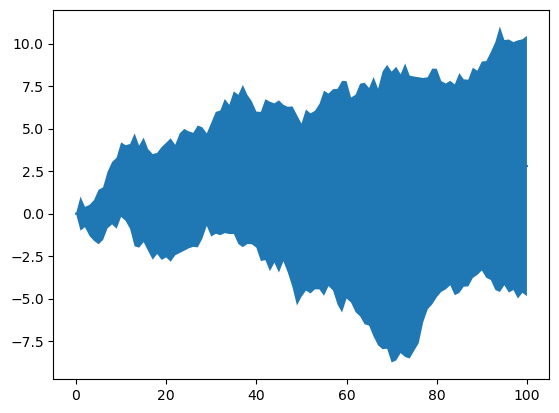

In [49]:
def es2(n, N):
    steps = np.random.choice(a=[1,-1], size = (N,n), p=probability)
    walks = np.zeros((N,n+1))
    walks[:,1:] = np.cumsum(steps, axis = 1)

    return walks.mean(axis=0), walks.std(axis=0)

n=100
N=10
medie, dev = es2(n,N)

plt.plot(np.arange(n+1), medie)
plt.fill_between(np.arange(n+1), medie-dev, medie+dev)

## Esercizio 3

Genera un array `a` di dimensioni **5 x 9** contenente numeri da una distribuzione gaussiana con media 0 e dev standard 1.  
Per ogni riga, seleziona il numero **più vicino a 0.1**.
Imposta il seed per la riproducibilità `np.random.seed(42)`

 *Suggerimento*: per ottenere `a[i, j]`, l'array `i` deve contenere gli **indici di riga** corrispondenti agli elementi in `j`.


In [54]:
import numpy as np

np.random.seed(42)
a = np.random.normal(0,1,size=(5,9))

target = 0.1
distanze = np.abs(a-target)
j = np.argmin(distanze, axis=1)
i = np.arange(a.shape[0])

a[i,j]


array([-0.1382643 ,  0.24196227,  0.11092259, -0.01349722,  0.17136828])

## Esercizio 4

Utilizza il dataset `titanic`, disponibile all'url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

Esegui un’analisi esplorativa sui dati dei passeggeri, focalizzandoti su tariffe, età e componenti familiari.

1. **Visualizza i primi 10 passeggeri ordinati per tariffa pagata** (`Fare`), dal più alto al più basso.

2. **Calcola la media** di:
   - `Age` (età)
   - `Fare` (tariffa)
   - `SibSp` (numero di fratelli/coniugi a bordo)

3. **Crea una nuova colonna** chiamata `Family_index`, definita come:

   $$
   \texttt{family\_index} = \frac{\texttt{sibsp} + \texttt{parch}}{\texttt{fare}}
   $$

   *(Indicatore del “peso familiare” per unità di spesa – attenzione a eventuali divisioni per zero!)*

4. Trova il **passeggero con il valore massimo** di `Family_index`.

5. **Filtra solo i passeggeri** che hanno pagato **più di 100** di tariffa (`Fare > 100`).

6. **Crea un grafico a barre** con i 10 passeggeri che hanno pagato di più (`Fare`).

7. **Crea un grafico a linee** dell’età (`Age`), ordinando i passeggeri per tariffa (`Fare`) crescente.



💡 *Suggerimenti*:
- Ricordati di gestire eventuali valori mancanti in `Age` o `Fare` prima di fare operazioni.


In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [57]:
df.sort_values(by="Fare", ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
...,...,...,...,...,...,...,...,...,...,...,...,...
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39.0,0,0,112050,0.0000,A36,S
815,816,0,1,"Fry, Mr. Richard",male,NaN,0,0,112058,0.0000,B102,S
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0000,NaN,S
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S


In [62]:
df["Age"].mean()
df["Fare"].mean()
df["SibSp"].mean()

np.float64(0.5230078563411896)

In [ ]:
df["Family_index"] = (df["SibSp"]+df["Parch"])/df["Fare"] #pandas mette in automatico Na dove ci sono gli zeri
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_index
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.137931
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0.014029
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.000000
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.018832
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0.000000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0.000000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0.127932
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0.000000


In [66]:
df["Family_index"].idxmax()
df.loc[df["Family_index"].idxmax()]

PassengerId                                  69
Survived                                      1
Pclass                                        3
Name            Andersson, Miss. Erna Alexandra
Sex                                      female
Age                                        17.0
SibSp                                         4
Parch                                         2
Ticket                                  3101281
Fare                                      7.925
Cabin                                       NaN
Embarked                                      S
Family_index                           0.757098
Name: 68, dtype: object

In [ ]:
passeggeri_high_fare = df[df["Fare"]>100]

passeggeri_to_plot = df.sort_values(by="Fare", ascending=False).head(10)
passeggeri_to_plot.reset_index(inplace=True) #resetti gli indici

<BarContainer object of 10 artists>

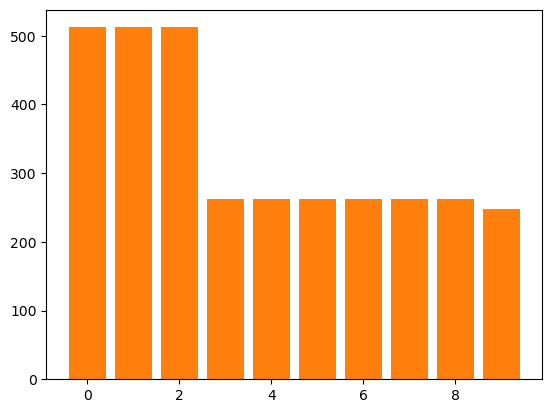

In [ ]:
plt.bar(passeggeri_to_plot.index, passeggeri_to_plot["Fare"])
# plt.bar(np.arange(10), passeggeri_to_plot["Fare"])

## Esercizio 5

Usa il dataset `penguins`, disponibile tramite `seaborn.load_dataset("penguins")`.


1. Quante righe e colonne ha il dataset?

2. Controlla quanti valori mancanti ci sono per colonna.

3. Riempi i valori mancanti nella colonna `sex` con il valore più frequente.

4. Rimuovi le righe in cui il valore `body_mass_g` è mancante.

5. Controlla se ci sono righe duplicate.

6. Calcola la **massa corporea media** (`body_mass_g`) per ogni specie (`species`).
  Se ci sono valori mancanti in `body_mass_g`, riempili con la media della specie.

7. Visualizza la **distribuzione della massa corporea** (`body_mass_g`) per specie.

8.  Visualizza la **distribuzione della massa corporea** per specie, **dividendo per sesso** (`sex`) e mostrandoli a confronto.


💡 Suggerimento: usa `seaborn.violinplot()`, `boxplot()` o `kdeplot()` con `hue='sex'`.


In [84]:
import pandas as pd
import matplotlib.pyplot 
import seaborn as sns
import numpy as np

df = sns.load_dataset("penguins")
df #344x7

df.isnull().sum()

df["sex"].mode()[0]
df["sex"].fillna(df["sex"].mode()[0], inplace = True)

df_clean= df.dropna(subset=["body_mass_g"])

df.duplicated().sum()

medie = df.groupby("species")["body_mass_g"].mean()
medie

C:\Users\margh\AppData\Local\Temp\ipykernel_20540\1796803302.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["sex"].fillna(df["sex"].mode()[0], inplace = True)


species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64

## Esercizio 6

Hai due array NumPy generati come segue:

`x = np.linspace(0, 10, 100)`  
`y = 3 * x + 2 + np.random.normal(0, 1, 100)`

Scrivi una funzione `fit_line(x, y)` che:

- usa `scipy.optimize.curve_fit` per eseguire un **fitting lineare** del tipo `y = a * x + b`;  
- restituisce una tupla contenente:
  - i **parametri ottimizzati** `a` e `b`;  
  - una **stringa** che descrive la retta trovata, ad esempio: `"y = 3.02 * x + 1.95"`.


Esempio di output atteso:   (3.02, 1.95, "y = 3.02 * x + 1.95")

Fai un esempio di utilizzo dove poi plotti i dati e la curva ottenuta.


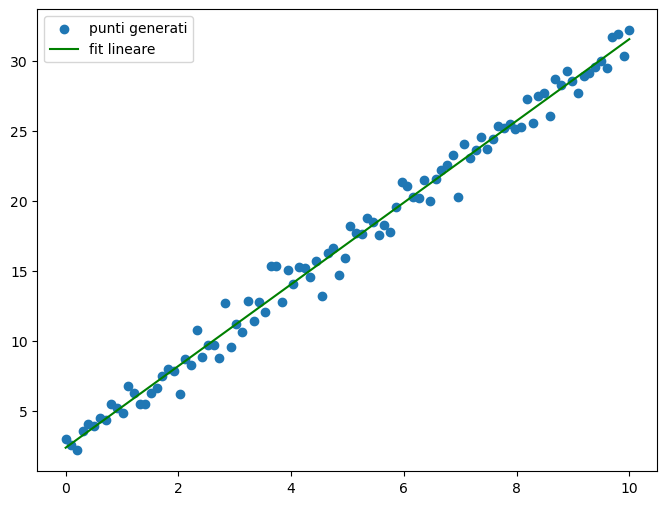

In [25]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 100)
y = 3 * x + 2 + np.random.normal(0, 1, 100)

def retta(x,a,b):
    return a*x+b

def fit_line(x,y):

    popt,_= sp.optimize.curve_fit(retta, x, y) #ora popt dentro ha in ordine a,b;
    
    a = popt[0]
    b = popt[1]

    stringa = f"y={a}*x+{b}"
    return a,b, stringa

a, b, stringa = fit_line(x, y)

x_1 = np.arange(11)
y_1 = retta(x_1, a, b)

plt.figure(figsize=(8,6))
plt.scatter(x,y, label="punti generati")
plt.plot(x_1, y_1, color="green", label="fit lineare")
plt.legend()





